In [1]:
import json
import math
import random
import os
from pathlib import Path
from typing import Optional, Tuple, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch.autograd import Function
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU   :', torch.cuda.get_device_name(0))
import shutil

Device: cuda
GPU   : NVIDIA GeForce RTX 4060


In [3]:
PIPE_CFG = {
'dapt_model_dir':           '../../dapt_lazada/',
'source_unlabeled_csv':     '../../datasets/telemedicine_preprocessed/test.csv',
'target_unlabeled_csv':     '../../datasets/lazada_train_preprocessed.csv',
'source_labeled_csv':       '../../datasets/telemedicine_preprocessed/train.csv',  
'target_eval_csv':          '../../datasets/lazada_test_preprocessed.csv',
'output_dir':               'outputs/adapter_stack',

'batch_size':               32,
'max_length':               128,
'epochs_domain':            3,
'epochs_task':              3,
'learning_rate':            1e-5,
'domain_adapter_lr':        1e-5,
'task_adapter_lr':          5e-4,
'weight_decay':             0.02,
'warmup_ratio':             0.1,
'dropout':                  0.2,
'domain_adapter_dim':       16,
'task_adapter_dim':         16,
'max_grad_norm':            1.0,
'unfreeze_top_layers':      4,
'label_smoothing':          0.0,
'early_stopping_patience':  3,
'early_stopping_min_delta': 1e-4,
'seed':                     42,
'use_focal_loss':           False,
'focal_gamma':              2.0,
'use_class_balanced_sampling': False,
'val_split':                0.15,
}

for k in ['dapt_model_dir','source_unlabeled_csv','target_unlabeled_csv',
          'source_labeled_csv','target_eval_csv']:
    print(f"{k:30s} -> {PIPE_CFG[k]}  exists={Path(PIPE_CFG[k]).exists()}")


dapt_model_dir                 -> ../../dapt_lazada/  exists=True
source_unlabeled_csv           -> ../../datasets/telemedicine_preprocessed/test.csv  exists=True
target_unlabeled_csv           -> ../../datasets/lazada_train_preprocessed.csv  exists=True
source_labeled_csv             -> ../../datasets/telemedicine_preprocessed/train.csv  exists=True
target_eval_csv                -> ../../datasets/lazada_test_preprocessed.csv  exists=True


In [4]:
LABEL2ID = {'negative': 0, 'positive': 1}
ID2LABEL  = {0: 'negative', 1: 'positive'}

def _resolve_text_column(df):
    for col in ['content', 'reviewContent', 'text', 'review']:
        if col in df.columns: return col
    raise ValueError(f'No text column found. Got: {df.columns.tolist()}')

def _resolve_label_column(df):
    for col in ['label', 'sentiment', 'target']:
        if col in df.columns: return col
    raise ValueError(f'No label column found. Got: {df.columns.tolist()}')

def _normalize_labels(series):
    return series.astype(str).str.strip().str.lower().replace({
        'pos':     'positive', 'neg':     'negative',
        '1':       'positive', '0':       'negative',
        'positif': 'positive', 'negatif': 'negative',
        'true':    'positive', 'false':   'negative',
    })

def clean_dataframe(df, text_col, label_col=None):
    cols = [text_col] + ([label_col] if label_col else [])
    out  = df[cols].copy().dropna(subset=[text_col])
    out[text_col] = out[text_col].astype(str).str.strip()
    out  = out[out[text_col] != '']
    if label_col:
        out = out.dropna(subset=[label_col])
        out[label_col] = _normalize_labels(out[label_col])
        out = out[out[label_col].isin(LABEL2ID)]
    return out.reset_index(drop=True)

def _verify_labels(df, label_col, path):
    """Raise immediately if label encoding failed or only one class survived."""
    assert len(df) > 0, f'No rows left after cleaning {path}. Check text/label columns.'
    n_classes = df[label_col].nunique()
    counts    = df[label_col].value_counts()
    print(f'  [{Path(path).name}] {len(df):,} rows | classes: {dict(counts)}')
    if n_classes < 2:
        raw = pd.read_csv(path)
        lc  = _resolve_label_column(raw)
        raise ValueError(
            f'Only {n_classes} class after normalisation in {path}.\n'
            f'Raw label values: {raw[lc].unique()}\n'
            f'Add this format to _normalize_labels().'
        )

class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128, labels=None):
        self.texts, self.labels     = texts, labels
        self.tokenizer, self.max_length = tokenizer, max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc  = self.tokenizer(str(self.texts[idx]), truncation=True,
                              max_length=self.max_length, padding='max_length',
                              return_tensors='pt')
        item = {k: enc[k].squeeze(0) for k in ['input_ids', 'attention_mask']}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

class UnlabeledTextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts, self.tokenizer, self.max_length = texts, tokenizer, max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), truncation=True,
                             max_length=self.max_length, padding='max_length',
                             return_tensors='pt')
        return {k: enc[k].squeeze(0) for k in ['input_ids', 'attention_mask']}


## Combined DAPT + Domain Adapter (GRL) + Task Adapter

In [5]:
import itertools

def make_unlabeled_loaders(tokenizer, source_path, target_path,
                            batch_size, max_length, seed):
    def _load(p):
        df = pd.read_csv(p); tc = _resolve_text_column(df)
        df = clean_dataframe(df, tc)
        assert len(df) > 0, f'Empty dataframe after cleaning: {p}'
        return UnlabeledTextDataset(df[tc].tolist(), tokenizer, max_length)

    src_ds = _load(source_path)
    tgt_ds = _load(target_path)

    # FIXED: separate generators so each loader gets independent shuffle
    g_src = torch.Generator(); g_src.manual_seed(seed)
    g_tgt = torch.Generator(); g_tgt.manual_seed(seed + 1)

    src_loader = DataLoader(src_ds, batch_size=batch_size, shuffle=True, generator=g_src)
    tgt_loader = DataLoader(tgt_ds, batch_size=batch_size, shuffle=True, generator=g_tgt)

    print(f'  Unlabeled loaders — source: {len(src_ds):,} rows | target: {len(tgt_ds):,} rows')
    print(f'  Steps per epoch will be: min({len(src_loader)}, {len(tgt_loader)}) = {min(len(src_loader), len(tgt_loader))}')
    return src_loader, tgt_loader

def make_labeled_loader(tokenizer, labeled_path, batch_size, max_length, seed,
                        val_split=0.0, use_class_balanced=False):
    """Load labeled CSV. If val_split > 0, returns (train_loader, val_loader)."""
    df = pd.read_csv(labeled_path)
    tc, lc = _resolve_text_column(df), _resolve_label_column(df)
    df = clean_dataframe(df, tc, lc)
    _verify_labels(df, lc, labeled_path)
    df['label_id'] = df[lc].map(LABEL2ID)

    if val_split > 0:
        from sklearn.model_selection import train_test_split as tts
        train_df, val_df = tts(df, test_size=val_split, random_state=seed,
                               stratify=df['label_id'])
        g_vl = torch.Generator(); g_vl.manual_seed(seed + 1)
        tr_ds = TextDataset(train_df[tc].tolist(), tokenizer, max_length,
                            train_df['label_id'].tolist())
        vl_ds = TextDataset(val_df[tc].tolist(),   tokenizer, max_length,
                            val_df['label_id'].tolist())
        if use_class_balanced:
            sampler = ClassBalancedSampler(train_df['label_id'].tolist())
            tr_loader = DataLoader(tr_ds, batch_size=batch_size, sampler=sampler)
        else:
            g_tr = torch.Generator(); g_tr.manual_seed(seed)
            tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, generator=g_tr)
        vl_loader = DataLoader(vl_ds, batch_size=batch_size, shuffle=False, generator=g_vl)
        return tr_loader, vl_loader

    g = torch.Generator(); g.manual_seed(seed)
    ds = TextDataset(df[tc].tolist(), tokenizer, max_length, df['label_id'].tolist())
    if use_class_balanced:
        sampler = ClassBalancedSampler(df['label_id'].tolist())
        return DataLoader(ds, batch_size=batch_size, sampler=sampler)
    return DataLoader(ds, batch_size=batch_size, shuffle=True, generator=g)


In [6]:
class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, inputs, alpha):
        ctx.alpha = alpha
        return inputs.view_as(inputs)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

class GradientReversalLayer(nn.Module):
    def forward(self, inputs, alpha=1.0):
        return GradientReversalFunction.apply(inputs, alpha)

In [7]:
class PfeifferAdapter(nn.Module):
    """Pfeiffer bottleneck adapter (2020): x + dropout(LayerNorm(up(gelu(down(x)))))"""
    def __init__(self, hidden_size, adapter_dim, dropout=0.1):
        super().__init__()
        self.down       = nn.Linear(hidden_size, adapter_dim)
        self.act        = nn.GELU()                       # matches BERT internals
        self.up         = nn.Linear(adapter_dim, hidden_size)
        self.layer_norm = nn.LayerNorm(hidden_size)       # stabilises residual add
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x):
        return x + self.dropout(self.layer_norm(self.up(self.act(self.down(x)))))

In [8]:
class DomainAdapterDANN(nn.Module):
    def __init__(self, base_model_dir, adapter_dim=16, dropout=0.1):
        super().__init__()
        self.encoder           = AutoModel.from_pretrained(base_model_dir)
        H                      = self.encoder.config.hidden_size
        self.dropout           = nn.Dropout(dropout)
        self.domain_adapter    = PfeifferAdapter(H, adapter_dim, dropout=dropout)
        self.grl               = GradientReversalLayer()
        self.domain_classifier = nn.Sequential(
            nn.Linear(H, H // 2), 
            nn.GELU(), 
            nn.Dropout(dropout), 
            nn.Linear(H // 2, 2),
        )

    def _mean_pool(self, input_ids, attention_mask):
        """Mean pool over real (non-padding) tokens — richer than CLS alone."""
        h    = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()   # (B, L, 1)
        return (h * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

    def forward(self, input_ids, attention_mask, alpha=1.0):
        feat    = self.dropout(self._mean_pool(input_ids, attention_mask))
        adapted = self.domain_adapter(feat)
        return self.domain_classifier(self.grl(adapted, alpha=alpha))


In [9]:
class TaskAdapterClassifier(nn.Module):
    def __init__(self, base_model_dir, domain_adapter_dim, task_adapter_dim, dropout=0.1):
        super().__init__()
        self.encoder        = AutoModel.from_pretrained(base_model_dir)
        H                   = self.encoder.config.hidden_size
        self.dropout        = nn.Dropout(dropout)
        self.domain_adapter = PfeifferAdapter(H, domain_adapter_dim, dropout=dropout)
        self.task_adapter   = PfeifferAdapter(H, task_adapter_dim,   dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(H, H // 2), 
            nn.GELU(), 
            nn.Dropout(dropout), 
            nn.Linear(H // 2, 2),
        )

    def _mean_pool(self, input_ids, attention_mask):
        """Mean pool over real tokens — richer signal than CLS for long/mixed reviews."""
        h    = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        return (h * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

    def extract_features(self, input_ids, attention_mask):
        feat = self.dropout(self._mean_pool(input_ids, attention_mask))
        return feat

    def forward(self, input_ids, attention_mask):
        feat = self.extract_features(input_ids, attention_mask)
        feat = self.domain_adapter(feat)
        feat = self.task_adapter(feat)
        return self.classifier(feat)


In [10]:
def freeze_module(module: nn.Module) -> None:
    for param in module.parameters():
        param.requires_grad = False

def unfreeze_module(module: nn.Module) -> None:
    for param in module.parameters():
        param.requires_grad = True
        
def _unfreeze_top_transformer_layers(encoder: nn.Module, num_layers: int) -> None:
    if num_layers <= 0:
        return
    if hasattr(encoder, 'encoder') and hasattr(encoder.encoder, 'layer'):
        layers = encoder.encoder.layer
        for layer in layers[-num_layers:]:
            unfreeze_module(layer)
    else:
        print('Warning: cannot find encoder layers to unfreeze; skipping.')

# ---------- Focal Loss for class imbalance ----------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits, targets,
            weight=self.weight,
            reduction='none',
            label_smoothing=self.label_smoothing,
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# ---------- Class-Balanced Sampler ----------
from torch.utils.data import Sampler
import collections

class ClassBalancedSampler(Sampler):
    def __init__(self, labels, num_samples_per_class=None):
        self.labels = list(labels)
        self.num_classes = len(set(self.labels))
        self.class_indices = collections.defaultdict(list)
        for idx, label in enumerate(self.labels):
            self.class_indices[label].append(idx)
        if num_samples_per_class is None:
            num_samples_per_class = max(len(v) for v in self.class_indices.values())
        self.num_samples_per_class = num_samples_per_class
        self.num_samples = num_samples_per_class * self.num_classes

    def __iter__(self):
        sampled = []
        for c in range(self.num_classes):
            indices = self.class_indices[c]
            if len(indices) < self.num_samples_per_class:
                resampled = indices.copy()
                while len(resampled) < self.num_samples_per_class:
                    resampled.append(np.random.choice(indices))
                sampled.extend(resampled)
            else:
                sampled.extend(np.random.choice(indices, self.num_samples_per_class, replace=False).tolist())
        np.random.shuffle(sampled)
        return iter(sampled)

    def __len__(self):
        return self.num_samples

In [11]:
@torch.no_grad()
def evaluate_classifier(model: TaskAdapterClassifier, dataloader: DataLoader, device_eval: torch.device):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    all_preds, all_labels = [], []
    total_loss = 0.0

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device_eval)
        attention_mask = batch['attention_mask'].to(device_eval)
        labels = batch['labels'].to(device_eval)

        logits = model(input_ids, attention_mask)
        loss = loss_fn(logits, labels)
        total_loss += loss.item()
        all_preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / max(1, len(dataloader))
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
    return {
        'loss': avg_loss,
        'acc': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

In [12]:
import itertools

def train_domain_adapter(cfg: dict, device_train: torch.device = None) -> Path:
    if device_train is None:
        device_train = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    set_seed(cfg['seed'])
    base_dir = cfg['dapt_model_dir']
    output_dir = Path(cfg['output_dir'])
    output_dir.mkdir(parents=True, exist_ok=True)
    domain_adapter_path = output_dir / 'domain_adapter.pt'
    domain_classifier_path = output_dir / 'domain_classifier.pt'

    tokenizer = AutoTokenizer.from_pretrained(base_dir)
    source_loader, target_loader = make_unlabeled_loaders(
        tokenizer=tokenizer,
        source_path=Path(cfg['source_unlabeled_csv']),
        target_path=Path(cfg['target_unlabeled_csv']),
        batch_size=cfg['batch_size'],
        max_length=cfg['max_length'],
        seed=cfg['seed'],
    )

    print(f'  Source loader: {len(source_loader)} batches | Target loader: {len(target_loader)} batches')

    model = DomainAdapterDANN(
        base_model_dir=base_dir,
        adapter_dim=cfg['domain_adapter_dim'],
        dropout=cfg['dropout'],
    ).to(device_train)

    freeze_module(model.encoder)
    unfreeze_module(model.domain_adapter)
    unfreeze_module(model.domain_classifier)

    domain_loss_fn = nn.CrossEntropyLoss()
    optimizer = AdamW(
        list(model.domain_adapter.parameters()) + list(model.domain_classifier.parameters()),
        lr=cfg['domain_adapter_lr'],
        weight_decay=cfg['weight_decay'],
    )

    # Use max so we see all data from the larger dataset; cycle handles the smaller one
    steps_per_epoch = max(len(source_loader), len(target_loader))
    total_steps = cfg['epochs_domain'] * steps_per_epoch
    warmup_steps = int(cfg['warmup_ratio'] * total_steps)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    global_step = 0
    for epoch in range(1, cfg['epochs_domain'] + 1):
        model.train()
        running_loss = 0.0
        # cycle() repeats the smaller dataset so no data is discarded
        source_iter = itertools.cycle(source_loader)
        target_iter = itertools.cycle(target_loader)
        progress = tqdm(range(steps_per_epoch), desc=f'Domain Epoch {epoch}/{cfg["epochs_domain"]}')
        for step_idx in progress:
            source_batch = next(source_iter)
            target_batch = next(target_iter)

            p = float(global_step) / max(1, total_steps - 1)
            alpha = 2.0 / (1.0 + math.exp(-10 * p)) - 1.0

            source_input_ids = source_batch['input_ids'].to(device_train)
            source_attention_mask = source_batch['attention_mask'].to(device_train)
            target_input_ids = target_batch['input_ids'].to(device_train)
            target_attention_mask = target_batch['attention_mask'].to(device_train)

            source_logits = model(source_input_ids, source_attention_mask, alpha=alpha)
            target_logits = model(target_input_ids, target_attention_mask, alpha=alpha)

            source_labels = torch.zeros(source_logits.size(0), dtype=torch.long, device=device_train)
            target_labels = torch.ones(target_logits.size(0), dtype=torch.long, device=device_train)

            loss_source = domain_loss_fn(source_logits, source_labels)
            loss_target = domain_loss_fn(target_logits, target_labels)
            loss = 0.5 * (loss_source + loss_target)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg['max_grad_norm'])
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            global_step += 1
            progress.set_postfix(loss=f'{running_loss/(step_idx+1):.4f}', alpha=f'{alpha:.3f}')

    torch.save(model.domain_adapter.state_dict(), domain_adapter_path)
    torch.save(model.domain_classifier.state_dict(), domain_classifier_path)
    tokenizer.save_pretrained(output_dir)
    print('Saved domain adapter to:', domain_adapter_path)
    return domain_adapter_path

In [13]:
def train_task_adapter(cfg: dict, domain_adapter_path: Path, device_train: torch.device = None) -> Path:
    if device_train is None:
        device_train = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    set_seed(cfg['seed'])
    base_dir = cfg['dapt_model_dir']
    output_dir = Path(cfg['output_dir'])
    output_dir.mkdir(parents=True, exist_ok=True)
    task_adapter_path = output_dir / 'task_adapter.pt'
    task_head_path = output_dir / 'task_classifier.pt'

    tokenizer = AutoTokenizer.from_pretrained(base_dir)
    val_split = cfg.get('val_split', 0.0)
    use_cb = cfg.get('use_class_balanced_sampling', False)
    result = make_labeled_loader(
        tokenizer=tokenizer,
        labeled_path=Path(cfg['source_labeled_csv']),
        batch_size=cfg['batch_size'],
        max_length=cfg['max_length'],
        seed=cfg['seed'],
        val_split=val_split,
        use_class_balanced=use_cb,
    )
    if val_split > 0:
        labeled_loader, val_loader = result
    else:
        labeled_loader, val_loader = result, None

    # Compute class weights for Focal Loss
    _tmp_df   = pd.read_csv(Path(cfg['source_labeled_csv']))
    _tc, _lc  = _resolve_text_column(_tmp_df), _resolve_label_column(_tmp_df)
    _tmp_df   = clean_dataframe(_tmp_df, _tc, _lc)
    _tmp_df['label_id'] = _tmp_df[_lc].map(LABEL2ID)
    _counts   = _tmp_df['label_id'].value_counts().sort_index()
    _total    = len(_tmp_df)
    _weights  = torch.tensor([_total / (2 * _counts[i]) for i in range(2)],
                              dtype=torch.float).to(device_train)
    print(f'  Dataset: {len(_tmp_df):,} labeled samples')
    print(f'  Class distribution: neg={_counts.get(0,0):,}, pos={_counts.get(1,0):,}')
    print(f'  Class weights: neg={_weights[0]:.3f}  pos={_weights[1]:.3f}')

    # Target eval loader for early stopping
    target_eval_loader = None
    target_eval_path = cfg.get('target_eval_csv')
    if target_eval_path:
        eval_path = Path(target_eval_path)
        if eval_path.exists():
            target_eval_loader = make_labeled_loader(
                tokenizer=tokenizer,
                labeled_path=eval_path,
                batch_size=cfg['batch_size'],
                max_length=cfg['max_length'],
                seed=cfg['seed'],
            )

    model = TaskAdapterClassifier(
        base_model_dir=base_dir,
        domain_adapter_dim=cfg['domain_adapter_dim'],
        task_adapter_dim=cfg['task_adapter_dim'],
        dropout=cfg['dropout'],
    ).to(device_train)

    if domain_adapter_path.exists():
        model.domain_adapter.load_state_dict(torch.load(domain_adapter_path, map_location=device_train))
    else:
        raise FileNotFoundError(f'Domain adapter not found: {domain_adapter_path}')

    freeze_module(model.encoder)
    freeze_module(model.domain_adapter)
    unfreeze_module(model.task_adapter)
    unfreeze_module(model.classifier)
    _unfreeze_top_transformer_layers(model.encoder, int(cfg.get('unfreeze_top_layers', 0)))

    # Use Focal Loss or weighted CrossEntropy
    use_focal = cfg.get('use_focal_loss', False)
    if use_focal:
        focal_gamma = cfg.get('focal_gamma', 2.0)
        loss_fn = FocalLoss(gamma=focal_gamma, weight=_weights, label_smoothing=cfg['label_smoothing'])
        print(f'  Using Focal Loss (gamma={focal_gamma})')
    else:
        loss_fn = nn.CrossEntropyLoss(weight=_weights, label_smoothing=cfg['label_smoothing'])
        print(f'  Using weighted CrossEntropyLoss (smoothing={cfg["label_smoothing"]})')
    
    # Collect trainable parameters with per-group learning rates
    trainable_params = [
        {'params': model.task_adapter.parameters(), 'lr': cfg['task_adapter_lr']},
        {'params': model.classifier.parameters(),   'lr': cfg['task_adapter_lr']},
    ]
    
    # Add unfrozen encoder layers if any (with conservative LR)
    if cfg.get('unfreeze_top_layers', 0) > 0:
        unfrozen_encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
        if unfrozen_encoder_params:
            trainable_params.append({'params': unfrozen_encoder_params, 'lr': cfg['learning_rate']})
    
    optimizer = AdamW(trainable_params, lr=cfg['task_adapter_lr'], weight_decay=cfg['weight_decay'])

    total_steps = cfg['epochs_task'] * len(labeled_loader)
    warmup_steps = int(cfg['warmup_ratio'] * total_steps)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    # ── Early stopping setup ─────────────────────────────────────────────────
    best_val_loss = float('inf'); es_counter = 0; best_epoch = 0
    best_task_adapter_path = output_dir / 'task_adapter_best.pt'
    best_task_head_path    = output_dir / 'task_classifier_best.pt'
    patience    = int(cfg.get('early_stopping_patience', 0))
    min_delta   = float(cfg.get('early_stopping_min_delta', 1e-4))
    use_es      = patience > 0 and (val_loader is not None or target_eval_loader is not None)
    es_loader   = val_loader if val_loader is not None else target_eval_loader
    if use_es:
        print(f'  Early stopping: patience={patience}, min_delta={min_delta}, using {"val_loader" if val_loader is not None else "target_eval"}')

    for epoch in range(1, cfg['epochs_task'] + 1):
        model.train()
        running_loss = 0.0
        progress = tqdm(labeled_loader, desc=f'Task Epoch {epoch}/{cfg["epochs_task"]}')
        for step_idx, batch in enumerate(progress, 1):
            input_ids = batch['input_ids'].to(device_train)
            attention_mask = batch['attention_mask'].to(device_train)
            labels = batch['labels'].to(device_train)

            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg['max_grad_norm'])
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            progress.set_postfix(loss=f'{running_loss/step_idx:.4f}')

        # ── Validation & early stopping ──────────────────────────────────
        if use_es and es_loader is not None:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for vb in es_loader:
                    v_ids = vb['input_ids'].to(device_train)
                    v_mask = vb['attention_mask'].to(device_train)
                    v_lab = vb['labels'].to(device_train)
                    v_logits = model(v_ids, v_mask)
                    val_loss += loss_fn(v_logits, v_lab).item()
            val_loss /= max(1, len(es_loader))
            print(f'  Epoch {epoch} val_loss={val_loss:.4f}')
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                es_counter = 0
                best_epoch = epoch
                torch.save(model.task_adapter.state_dict(), best_task_adapter_path)
                torch.save(model.classifier.state_dict(), best_task_head_path)
                print(f'  -> Saved best model (val_loss={val_loss:.4f})')
            else:
                es_counter += 1
                print(f'  -> No improvement ({es_counter}/{patience})')
                if es_counter >= patience:
                    print(f'  Early stopping at epoch {epoch}. Best epoch: {best_epoch}')
                    break

    # Load best model if early stopping was used
    if use_es and best_task_adapter_path.exists():
        model.task_adapter.load_state_dict(torch.load(best_task_adapter_path, map_location=device_train))
        model.classifier.load_state_dict(torch.load(best_task_head_path, map_location=device_train))
        print(f'  Loaded best model from epoch {best_epoch}')

    torch.save(model.task_adapter.state_dict(), task_adapter_path)
    torch.save(model.classifier.state_dict(), task_head_path)
    tokenizer.save_pretrained(output_dir)
    print('Saved task adapter to:', task_adapter_path)

    print('\nSource labeled evaluation:')
    source_metrics = evaluate_classifier(model, labeled_loader, device_train)
    print(source_metrics)

    # Also evaluate on held-out test set
    test_path = Path(cfg['source_labeled_csv']).parent / 'test.csv'
    if test_path.exists() and str(test_path) != str(cfg['source_labeled_csv']):
        print('\nHeld-out test evaluation:')
        test_loader = make_labeled_loader(
            tokenizer=tokenizer, labeled_path=test_path,
            batch_size=cfg['batch_size'], max_length=cfg['max_length'], seed=cfg['seed'],
        )
        test_metrics = evaluate_classifier(model, test_loader, device_train)
        print(test_metrics)

    if target_eval_loader is not None:
        print('\nTarget labeled evaluation:')
        target_metrics = evaluate_classifier(model, target_eval_loader, device_train)
        print(target_metrics)
    else:
        print('\nTarget labeled evaluation: skipped (target_eval_csv not found)')

    return task_adapter_path

In [14]:
# Clear stale checkpoints before every run to avoid loading old broken weights
out_dir = Path(PIPE_CFG['output_dir'])
if out_dir.exists():
    shutil.rmtree(out_dir)
    print(f'Cleared stale checkpoints: {out_dir}')

domain_adapter_path = train_domain_adapter(PIPE_CFG, device_train=device)
task_adapter_path   = train_task_adapter(PIPE_CFG, domain_adapter_path, device_train=device)


Some weights of BertModel were not initialized from the model checkpoint at ../../dapt_lazada/ and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Cleared stale checkpoints: outputs\adapter_stack
  Unlabeled loaders — source: 1,674 rows | target: 8,142 rows
  Steps per epoch will be: min(53, 255) = 53
  Source loader: 53 batches | Target loader: 255 batches


Domain Epoch 1/3:   0%|          | 0/255 [00:00<?, ?it/s]

Domain Epoch 2/3:   0%|          | 0/255 [00:00<?, ?it/s]

Domain Epoch 3/3:   0%|          | 0/255 [00:00<?, ?it/s]

...

  Epoch 1 val_loss=0.2102
  -> Saved best model (val_loss=0.2102)


Task Epoch 2/3:   0%|          | 0/178 [00:00<?, ?it/s]

  Epoch 2 val_loss=0.1904
  -> Saved best model (val_loss=0.1904)


Task Epoch 3/3:   0%|          | 0/178 [00:00<?, ?it/s]

  Epoch 3 val_loss=0.2038
  -> No improvement (1/3)
  Loaded best model from epoch 2
Saved task adapter to: outputs\adapter_stack\task_adapter.pt

Source labeled evaluation:
{'loss': 0.1291147999235251, 'acc': 0.9553681251098225, 'precision': 0.9554582367470142, 'recall': 0.9553681251098225, 'f1': 0.9553659752360862}

Held-out test evaluation:
  [test.csv] 1,674 rows | classes: {'negative': 837, 'positive': 837}
{'loss': 0.17004274931859295, 'acc': 0.9396654719235364, 'precision': 0.9398067235529969, 'recall': 0.9396654719235364, 'f1': 0.9396606271620324}

Target labeled evaluation:
{'loss': 0.4498048033565283, 'acc': 0.8432908912830558, 'precision': 0.8448103586158561, 'recall': 0.8432908912830558, 'f1': 0.8431117893105802}


## Inference 

In [15]:
def load_stacked_model(cfg: dict, device_override: Optional[torch.device] = None):
    if device_override is None:
        device_override = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    base_dir = cfg['dapt_model_dir']
    output_dir = Path(cfg['output_dir'])
    domain_adapter_path = output_dir / 'domain_adapter.pt'
    task_adapter_path = output_dir / 'task_adapter.pt'
    task_head_path = output_dir / 'task_classifier.pt'

    for path in [domain_adapter_path, task_adapter_path, task_head_path]:
        if not path.exists():
            raise FileNotFoundError(f'Missing checkpoint: {path}')

    tokenizer_dir = output_dir if (output_dir / 'tokenizer.json').exists() else base_dir
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir)

    model = TaskAdapterClassifier(
        base_model_dir=base_dir,
        domain_adapter_dim=cfg['domain_adapter_dim'],
        task_adapter_dim=cfg['task_adapter_dim'],
        dropout=cfg['dropout'],
    ).to(device_override)

    model.domain_adapter.load_state_dict(torch.load(domain_adapter_path, map_location=device_override))
    model.task_adapter.load_state_dict(torch.load(task_adapter_path, map_location=device_override))
    model.classifier.load_state_dict(torch.load(task_head_path, map_location=device_override))
    model.eval()

    return model, tokenizer, device_override

@torch.no_grad()
def predict_texts_stacked(
    model: TaskAdapterClassifier,
    tokenizer,
    texts: List[str],
    device_infer: torch.device,
    max_length: int = 128,
    batch_size: int = 16,
    ):
    rows = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        encoding = tokenizer(
            batch_texts,
            truncation=True,
            padding=True, 
            max_length=max_length,
            return_tensors='pt',
        )

        input_ids = encoding['input_ids'].to(device_infer)
        attention_mask = encoding['attention_mask'].to(device_infer)
        logits = model(input_ids, attention_mask)
        probs = F.softmax(logits, dim=1).cpu()

        for i, text in enumerate(batch_texts):
            sentiment_id = int(torch.argmax(probs[i]).item())
            rows.append({
                'text': text,
                'sentiment_id': sentiment_id,
                'sentiment_label': ID2LABEL[sentiment_id],
                'sentiment_negative_prob': float(probs[i][0].item()),
                'sentiment_positive_prob': float(probs[i][1].item()),
            })

    return rows

def print_results(rows: List[dict], max_rows: int = 20):
    preview = rows[:max_rows]
    if not preview:
        print('No predictions.')
        return

    print(f'Showing {len(preview)} / {len(rows)} predictions')
    print('=' * 80)
    for i, row in enumerate(preview, 1):
        print(f'[{i}] sentiment={row["sentiment_label"]} (neg={row["sentiment_negative_prob"]:.4f}, pos={row["sentiment_positive_prob"]:.4f})')
        print(f'    text={row["text"]}')
        print('-' * 80)

# Example run (uncomment to execute):
model, tokenizer, infer_device = load_stacked_model(PIPE_CFG)
texts = [
    "Produk ini kualitasnya sangat bagus, pengiriman cepat dan sesuai deskripsi.",
    "Barang yang saya terima rusak dan tidak berfungsi dengan baik, sangat mengecewakan.",
    "Harga cukup terjangkau tapi kualitasnya kurang memuaskan untuk pemakaian jangka panjang.",
    "Pantainya sangat indah, airnya jernih dan suasananya tenang cocok untuk liburan.",
    "Tempatnya kotor dan banyak sampah, fasilitas juga kurang terawat.",
    "Pemandangan cukup bagus tapi akses menuju lokasi cukup sulit dan jalan rusak.",
]
rows = predict_texts_stacked(
    model=model,
    tokenizer=tokenizer,
    texts=texts,
    device_infer=infer_device,
    max_length=PIPE_CFG['max_length'],
    batch_size=PIPE_CFG['batch_size'],
)
print_results(rows)
pd.DataFrame(rows)

Some weights of BertModel were not initialized from the model checkpoint at ../../dapt_lazada/ and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Showing 6 / 6 predictions
[1] sentiment=positive (neg=0.0371, pos=0.9629)
    text=Produk ini kualitasnya sangat bagus, pengiriman cepat dan sesuai deskripsi.
--------------------------------------------------------------------------------
[2] sentiment=positive (neg=0.2071, pos=0.7929)
    text=Barang yang saya terima rusak dan tidak berfungsi dengan baik, sangat mengecewakan.
--------------------------------------------------------------------------------
[3] sentiment=positive (neg=0.1224, pos=0.8776)
    text=Harga cukup terjangkau tapi kualitasnya kurang memuaskan untuk pemakaian jangka panjang.
--------------------------------------------------------------------------------
[4] sentiment=positive (neg=0.0777, pos=0.9223)
    text=Pantainya sangat indah, airnya jernih dan suasananya tenang cocok untuk liburan.
--------------------------------------------------------------------------------
[5] sentiment=positive (neg=0.2764, pos=0.7236)
    text=Tempatnya kotor dan banyak sampah, 

,text,sentiment_id,sentiment_label,sentiment_negative_prob,sentiment_positive_prob
0,"Produk ini kualitasnya sangat bagus, pengirima...",1,positive,0.037071,0.962929
1,Barang yang saya terima rusak dan tidak berfun...,1,positive,0.207051,0.792949
2,Harga cukup terjangkau tapi kualitasnya kurang...,1,positive,0.122412,0.877588
3,"Pantainya sangat indah, airnya jernih dan suas...",1,positive,0.077731,0.922269
4,"Tempatnya kotor dan banyak sampah, fasilitas j...",1,positive,0.276450,0.723550
5,Pemandangan cukup bagus tapi akses menuju loka...,1,positive,0.214517,0.785483


In [16]:
sns.set(style="whitegrid")

def extract_embeddings_from_dataloader(model, dataloader, device, stage="encoder+domain+task"):
    """Extract embeddings from a dataloader for a given stage."""
    model.eval()
    Xs = []
    Ys = []

    domain_adapter = getattr(model, 'domain_adapter', None)
    task_adapter = getattr(model, 'task_adapter', getattr(model, 'label_adapter', None))

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            feats = model.extract_features(input_ids=input_ids, attention_mask=attention_mask)

            if stage in ('encoder+domain', 'encoder+domain+task') and domain_adapter is not None:
                feats = domain_adapter(feats)
            if stage in ('encoder+task', 'encoder+domain+task') and task_adapter is not None:
                feats = task_adapter(feats)

            Xs.append(feats.cpu().numpy())
            if 'labels' in batch:
                Ys.append(batch['labels'].cpu().numpy())
            else:
                Ys.append(np.full((feats.size(0),), -1, dtype=int))

    if len(Xs) == 0:
        return np.zeros((0, model.encoder.config.hidden_size)), np.array([])

    X = np.concatenate(Xs, axis=0)
    Y = np.concatenate(Ys, axis=0)
    return X, Y

def project_embeddings(X, method="umap", n_components=2, random_state=42):
    if X.shape[0] == 0:
        return X
    
    if method == 'tsne':
        if X.shape[1] > 50:
            p = PCA(n_components=50, random_state=random_state).fit_transform(X)
        else:
            p = X
        ts = TSNE(n_components=n_components, random_state=random_state, init='pca', perplexity=30)
        return ts.fit_transform(p)

    pca = PCA(n_components=n_components, random_state=random_state)
    return pca.fit_transform(X)

def plot_single_panel(proj, labels, domains, title, outpath=None, figsize=(7, 6)):
    """Plot a single projection panel with legend inside plot."""
    palette = {
        ('source', 0): '#d62728',
        ('source', 1): '#1f77b4',
        ('target', 0): '#2ca02c',
        ('target', 1): '#9467bd',
    }
    display_names = {
        ('source', 0): 'source negative',
        ('source', 1): 'source positive',
        ('target', 0): 'target negative',
        ('target', 1): 'target positive',
    }
    plot_order = [('source', 0), ('source', 1), ('target', 0), ('target', 1)]

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    domains_np = np.array(domains)
    
    plt.axis(True)

    xs, ys = proj[:, 0], proj[:, 1]
    for dom, lab in plot_order:
        mask = (domains_np == dom) & (labels == lab)
        if mask.sum() == 0:
            continue
        ax.scatter(
            xs[mask],
            ys[mask],
            s=10,
            c=palette[(dom, lab)],
            label=display_names[(dom, lab)],
            alpha=0.8,
        )

    ax.set_title(title, fontsize=18)
    ax.grid(False)

    ax.legend(loc='upper left', fontsize=14, frameon=True, markerscale=2)

    fig.tight_layout()
    if outpath:
        os.makedirs(os.path.dirname(outpath), exist_ok=True)
        fig.savefig(outpath, dpi=200)
    plt.show()

Some weights of BertModel were not initialized from the model checkpoint at ../../dapt_lazada/ and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  [train.csv] 6,696 rows | classes: {'negative': 3348, 'positive': 3348}
  [lazada_test_preprocessed.csv] 2,042 rows | classes: {'positive': 1022, 'negative': 1020}


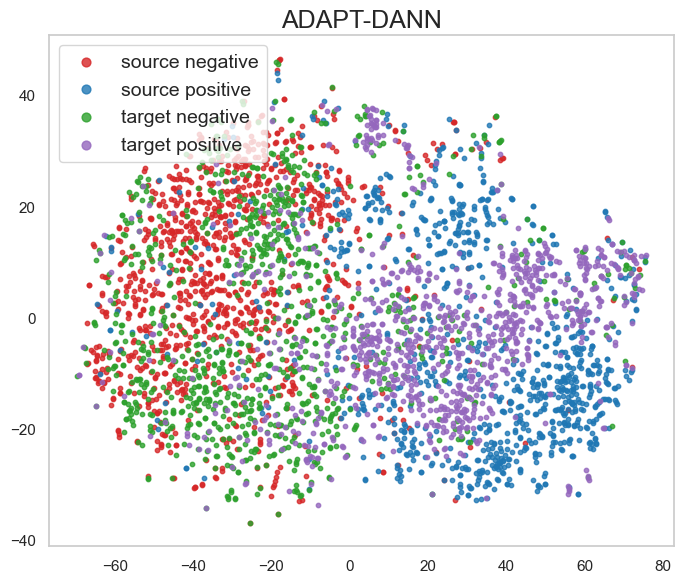

Saved visualization to: outputs\adapter_stack\embeddings_visualization_single_tsne.png


In [17]:
# === Run extraction and plot single-panel visualization ===
from pathlib import Path

device_vis = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load trained stacked model (expects files in PIPE_CFG['output_dir'])
model, tokenizer, _ = load_stacked_model(PIPE_CFG, device_override=device_vis)

# Build labeled loaders for source and target evaluation
src_loader = make_labeled_loader(
    tokenizer,
    Path(PIPE_CFG['source_labeled_csv']),
    batch_size=PIPE_CFG['batch_size'],
    max_length=PIPE_CFG['max_length'],
    seed=PIPE_CFG['seed'],
)
if PIPE_CFG.get('target_eval_csv') and Path(PIPE_CFG['target_eval_csv']).exists():
    tgt_loader = make_labeled_loader(
        tokenizer,
        Path(PIPE_CFG['target_eval_csv']),
        batch_size=PIPE_CFG['batch_size'],
        max_length=PIPE_CFG['max_length'],
        seed=PIPE_CFG['seed'],
    )
else:
    raise FileNotFoundError('target_eval_csv missing; provide labeled target set to visualize.')

# Optional: limit samples per domain to speed up visualization
def limited_batches(loader, max_samples=4000):
    cnt = 0
    for batch in loader:
        bsize = batch['input_ids'].size(0)
        if cnt + bsize > max_samples:
            remain = max_samples - cnt
            if remain <= 0:
                break
            for k in batch:
                if isinstance(batch[k], torch.Tensor):
                    batch[k] = batch[k][:remain]
            yield batch
            break
        yield batch
        cnt += bsize

max_per_domain = 2000
src_batches = list(limited_batches(src_loader, max_samples=max_per_domain))
tgt_batches = list(limited_batches(tgt_loader, max_samples=max_per_domain))

# Helper to use our extractor which expects an iterator of batches
def batches_iter(batches):
    for b in batches:
        yield b

# Match the simpler single-panel style used in dann_adapter_v2
stage = 'encoder+domain+task'

Xs_src, Ys_src = extract_embeddings_from_dataloader(
    model,
    batches_iter(src_batches),
    device_vis,
    stage=stage,
)
Xs_tgt, Ys_tgt = extract_embeddings_from_dataloader(
    model,
    batches_iter(tgt_batches),
    device_vis,
    stage=stage,
)

X = np.concatenate([Xs_src, Xs_tgt], axis=0)
Y = np.concatenate([Ys_src, Ys_tgt], axis=0)
domains = ['source'] * Xs_src.shape[0] + ['target'] * Xs_tgt.shape[0]

method = 'tsne'
proj = project_embeddings(X, method=method, n_components=2, random_state=42)

outpath = Path(PIPE_CFG['output_dir']) / f'embeddings_visualization_single_{method}.png'
plot_single_panel(
    proj,
    Y,
    domains,
    title='ADAPT-DANN',
    outpath=str(outpath),
    figsize=(7, 6),
)
print(f'Saved visualization to: {outpath}')

Some weights of BertModel were not initialized from the model checkpoint at ../../dapt_lazada/ and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  [train.csv] 6,696 rows | classes: {'negative': 3348, 'positive': 3348}
  Class weights: neg=1.000  pos=1.000


Task Epoch 1/3:   0%|          | 0/168 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.3154 train_acc=0.8702 | val_loss=0.2301 val_acc=0.9299


Task Epoch 2/3:   0%|          | 0/168 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.1892 train_acc=0.9300 | val_loss=0.1934 val_acc=0.9381


Task Epoch 3/3:   0%|          | 0/168 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.1605 train_acc=0.9442 | val_loss=0.1914 val_acc=0.9418
Saved task adapter to: outputs\adapter_stack\task_adapter.pt
Saved classifier to : outputs\adapter_stack\task_classifier.pt
Saved loss curve to: outputs\adapter_stack\task_learning_curves_loss.png


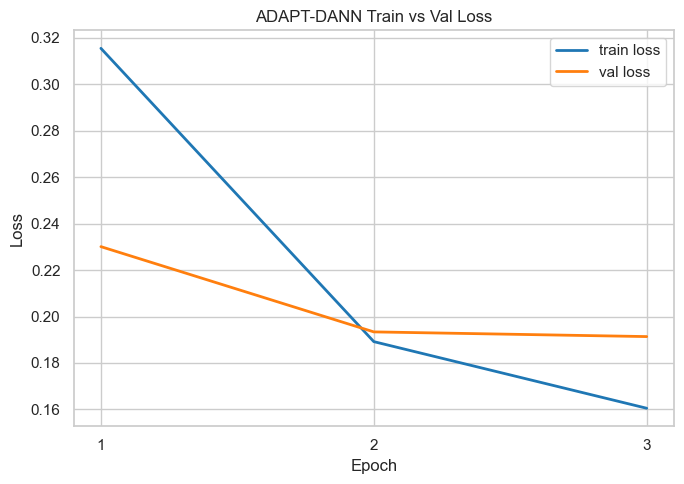

Saved accuracy curve to: outputs\adapter_stack\task_learning_curves_accuracy.png


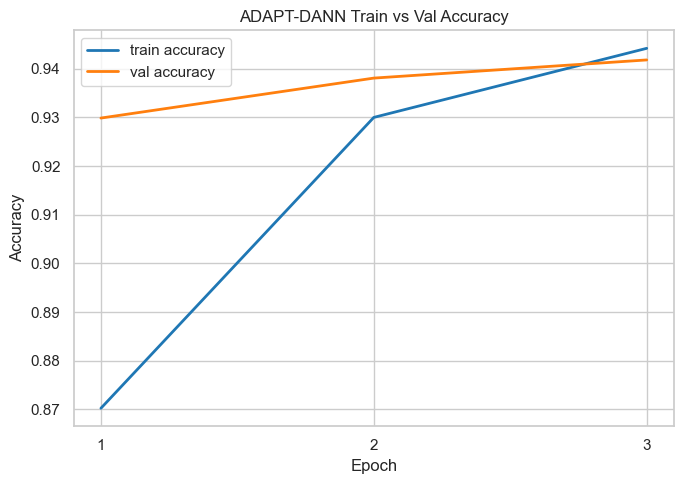

,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.315420,0.870239,0.230069,0.929851
1,2,0.189184,0.929985,0.193376,0.938060
2,3,0.160513,0.944175,0.191358,0.941791


In [18]:
def train_task_adapter_with_history(cfg: dict, domain_adapter_path: Path, device_train: torch.device = None, val_split: float = 0.2):
    """Train the task adapter and record loss/accuracy for training and validation."""
    if device_train is None:
        device_train = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    set_seed(cfg['seed'])
    base_dir = cfg['dapt_model_dir']
    output_dir = Path(cfg['output_dir'])
    output_dir.mkdir(parents=True, exist_ok=True)

    task_adapter_path = output_dir / 'task_adapter.pt'
    task_head_path = output_dir / 'task_classifier.pt'
    best_task_adapter_path = output_dir / 'task_adapter_best.pt'
    best_task_head_path = output_dir / 'task_classifier_best.pt'

    tokenizer = AutoTokenizer.from_pretrained(base_dir)
    train_loader, val_loader = make_labeled_loader(
        tokenizer=tokenizer,
        labeled_path=Path(cfg['source_labeled_csv']),
        batch_size=cfg['batch_size'],
        max_length=cfg['max_length'],
        seed=cfg['seed'],
        val_split=val_split,
    )

    # Recompute class weights from the full labeled source set
    _tmp_df = pd.read_csv(Path(cfg['source_labeled_csv']))
    _tc, _lc = _resolve_text_column(_tmp_df), _resolve_label_column(_tmp_df)
    _tmp_df = clean_dataframe(_tmp_df, _tc, _lc)
    _tmp_df['label_id'] = _tmp_df[_lc].map(LABEL2ID)
    _counts = _tmp_df['label_id'].value_counts().sort_index()
    _total = len(_tmp_df)
    _weights = torch.tensor([_total / (2 * _counts[i]) for i in range(2)], dtype=torch.float).to(device_train)
    print(f'  Class weights: neg={_weights[0]:.3f}  pos={_weights[1]:.3f}')

    model = TaskAdapterClassifier(
        base_model_dir=base_dir,
        domain_adapter_dim=cfg['domain_adapter_dim'],
        task_adapter_dim=cfg['task_adapter_dim'],
        dropout=cfg['dropout'],
    ).to(device_train)

    if domain_adapter_path.exists():
        model.domain_adapter.load_state_dict(torch.load(domain_adapter_path, map_location=device_train))
    else:
        raise FileNotFoundError(f'Domain adapter not found: {domain_adapter_path}')

    freeze_module(model.encoder)
    freeze_module(model.domain_adapter)
    unfreeze_module(model.task_adapter)
    unfreeze_module(model.classifier)
    _unfreeze_top_transformer_layers(model.encoder, int(cfg.get('unfreeze_top_layers', 0)))

    loss_fn = nn.CrossEntropyLoss(weight=_weights, label_smoothing=cfg['label_smoothing'])

    trainable_params = [
        {'params': model.task_adapter.parameters(), 'lr': cfg['task_adapter_lr']},
        {'params': model.classifier.parameters(), 'lr': cfg['task_adapter_lr']},
    ]
    if cfg.get('unfreeze_top_layers', 0) > 0:
        unfrozen_encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
        if unfrozen_encoder_params:
            trainable_params.append({'params': unfrozen_encoder_params, 'lr': cfg['learning_rate']})

    optimizer = AdamW(trainable_params, lr=cfg['task_adapter_lr'], weight_decay=cfg['weight_decay'])
    total_steps = cfg['epochs_task'] * len(train_loader)
    warmup_steps = int(cfg['warmup_ratio'] * total_steps)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    history = {
        'epoch': [],
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    patience = int(cfg.get('early_stopping_patience', 0))
    min_delta = float(cfg.get('early_stopping_min_delta', 1e-4))
    best_val_loss = float('inf')
    es_counter = 0
    best_epoch = 0

    for epoch in range(1, cfg['epochs_task'] + 1):
        model.train()
        running_loss = 0.0
        all_preds = []
        all_labels = []

        progress = tqdm(train_loader, desc=f'Task Epoch {epoch}/{cfg["epochs_task"]}')
        for step_idx, batch in enumerate(progress, 1):
            input_ids = batch['input_ids'].to(device_train)
            attention_mask = batch['attention_mask'].to(device_train)
            labels = batch['labels'].to(device_train)

            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg['max_grad_norm'])
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            all_preds.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())
            all_labels.extend(labels.detach().cpu().tolist())
            progress.set_postfix(loss=f'{running_loss / step_idx:.4f}')

        train_loss = running_loss / max(1, len(train_loader))
        train_acc = accuracy_score(all_labels, all_preds)
        val_metrics = evaluate_classifier(model, val_loader, device_train)

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['acc'])

        print(
            f'Epoch {epoch:02d} | '
            f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
            f'val_loss={val_metrics["loss"]:.4f} val_acc={val_metrics["acc"]:.4f}'
        )

        # Early stopping on validation loss
        if val_metrics['loss'] < best_val_loss - min_delta:
            best_val_loss = val_metrics['loss']
            best_epoch = epoch
            es_counter = 0
            torch.save(model.task_adapter.state_dict(), best_task_adapter_path)
            torch.save(model.classifier.state_dict(), best_task_head_path)
        else:
            es_counter += 1
            if patience > 0:
                print(f'  no improvement ({es_counter}/{patience})')
            if patience > 0 and es_counter >= patience:
                print(f'  early stopping at epoch {epoch}; best epoch was {best_epoch}')
                break

    if best_task_adapter_path.exists() and best_task_head_path.exists():
        model.task_adapter.load_state_dict(torch.load(best_task_adapter_path, map_location=device_train))
        model.classifier.load_state_dict(torch.load(best_task_head_path, map_location=device_train))

    torch.save(model.task_adapter.state_dict(), task_adapter_path)
    torch.save(model.classifier.state_dict(), task_head_path)
    tokenizer.save_pretrained(output_dir)

    print('Saved task adapter to:', task_adapter_path)
    print('Saved classifier to :', task_head_path)
    return model, history


def plot_learning_curves(history: dict, outpath: str = None):
    """Plot training vs validation loss and accuracy as two separate figures."""
    import numpy as _np
    from scipy.interpolate import make_interp_spline

    epochs = history['epoch']
    epochs_arr = _np.array(list(epochs), dtype=float)

    def _smooth_plot(ax, x_pts, y_pts, color, label):
        """Draw a smooth cubic spline through the data points — no dot markers."""
        x = _np.array(x_pts, dtype=float)
        y = _np.array(y_pts, dtype=float)
        if len(x) >= 4:
            x_fine = _np.linspace(x[0], x[-1], 300)
            spline = make_interp_spline(x, y, k=3)
            ax.plot(x_fine, spline(x_fine), color=color, linewidth=2, label=label)
        else:
            ax.plot(x, y, color=color, linewidth=2, label=label)

    # ── Figure 1 : Loss ──────────────────────────────────────────────────────
    fig_loss, ax_loss = plt.subplots(figsize=(7, 5))
    _smooth_plot(ax_loss, epochs_arr, history['train_loss'], color='tab:blue',   label='train loss')
    _smooth_plot(ax_loss, epochs_arr, history['val_loss'],   color='tab:orange', label='val loss')
    ax_loss.set_title('ADAPT-DANN Train vs Val Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_xticks([int(e) for e in epochs])
    ax_loss.legend()
    ax_loss.grid(True)
    fig_loss.tight_layout()
    if outpath:
        loss_path = str(outpath).replace('.png', '_loss.png')
        os.makedirs(os.path.dirname(loss_path), exist_ok=True)
        fig_loss.savefig(loss_path, dpi=200, bbox_inches='tight')
        print('Saved loss curve to:', loss_path)
    plt.show()

    # ── Figure 2 : Accuracy ──────────────────────────────────────────────────
    fig_acc, ax_acc = plt.subplots(figsize=(7, 5))
    _smooth_plot(ax_acc, epochs_arr, history['train_acc'], color='tab:blue',   label='train accuracy')
    _smooth_plot(ax_acc, epochs_arr, history['val_acc'],   color='tab:orange', label='val accuracy')
    ax_acc.set_title('ADAPT-DANN Train vs Val Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_xticks([int(e) for e in epochs])
    ax_acc.legend()
    ax_acc.grid(True)
    fig_acc.tight_layout()
    if outpath:
        acc_path = str(outpath).replace('.png', '_accuracy.png')
        fig_acc.savefig(acc_path, dpi=200, bbox_inches='tight')
        print('Saved accuracy curve to:', acc_path)
    plt.show()


# Example run:
# This will retrain the task stage and produce curves for overfitting analysis.
curve_dir = Path(PIPE_CFG['output_dir'])
curve_dir.mkdir(parents=True, exist_ok=True)

# Reuse the existing domain adapter if it already exists, otherwise train it first.
domain_adapter_path = curve_dir / 'domain_adapter.pt'
if not domain_adapter_path.exists():
    domain_adapter_path = train_domain_adapter(PIPE_CFG, device_train=device)

model_curve, history = train_task_adapter_with_history(
    PIPE_CFG,
    domain_adapter_path,
    device_train=device,
    val_split=0.2,
)

plot_learning_curves(history, outpath=curve_dir / 'task_learning_curves.png')
pd.DataFrame(history)
